In [2]:
from qiskit import QuantumCircuit
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt

%matplotlib inline

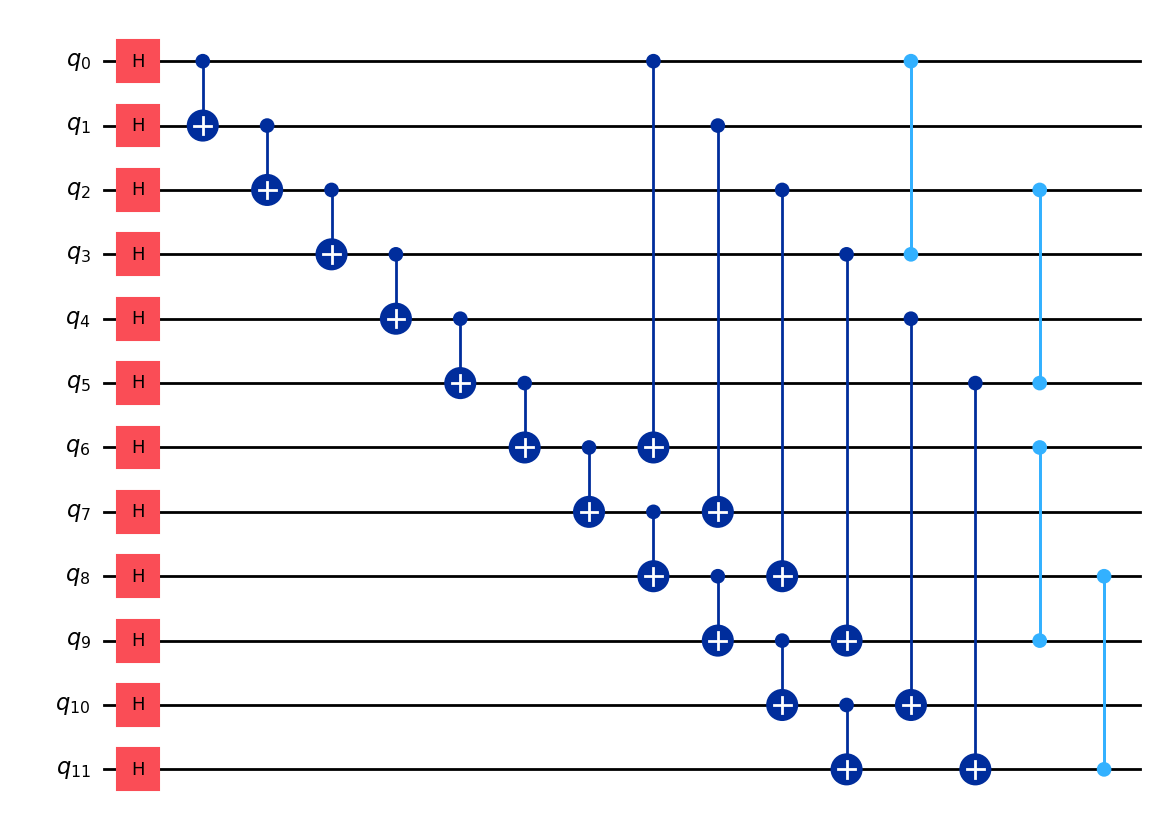

In [3]:


qc = QuantumCircuit(12)

for i in range(12):
    qc.h(i)

for i in range(11):
    qc.cx(i, i+1)

qc.cx(0,6)
qc.cx(1,7)
qc.cx(2,8)
qc.cx(3,9)
qc.cx(4,10)
qc.cx(5,11)

qc.cz(0,3)
qc.cz(2,5)
qc.cz(6,9)
qc.cz(8,11)

qc.draw("mpl");

In [4]:


G = nx.Graph()

for q in range(qc.num_qubits):
    G.add_node(q)

for instruction in qc.data:

    if len(instruction.qubits) == 2:

        q0 = qc.qubits.index(instruction.qubits[0])
        q1 = qc.qubits.index(instruction.qubits[1])

        gate_name = instruction.operation.name

        G.add_edge(q0, q1, gate=gate_name)

print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))

Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Edges: [(0, 1), (0, 6), (0, 3), (1, 2), (1, 7), (2, 3), (2, 8), (2, 5), (3, 4), (3, 9), (4, 5), (4, 10), (5, 6), (5, 11), (6, 7), (6, 9), (7, 8), (8, 9), (8, 11), (9, 10), (10, 11)]


In [5]:
from networkx.algorithms.community import kernighan_lin_bisection

partA, partB = kernighan_lin_bisection(G)

partA = set(partA)
partB = set(partB)

In [6]:

cut_edges = []

for u, v, data in G.edges(data=True):

    if (u in partA and v in partB) or \
        (u in partB and v in partA):

         cut_edges.append((u, v, data["gate"]))

minimum_cut_count = len(cut_edges)

        


In [7]:
print("Group A =", sorted(partA))
print("Group B =", sorted(partB))

print("\nCut Gates:")

for u, v, gate in cut_edges:
    print(f"{gate.upper()} between q{u} and q{v}")

print("\nTotal Cuts =", minimum_cut_count)

Group A = [3, 4, 8, 9, 10, 11]
Group B = [0, 1, 2, 5, 6, 7]

Cut Gates:
CZ between q0 and q3
CX between q2 and q3
CX between q2 and q8
CX between q4 and q5
CX between q5 and q11
CZ between q6 and q9
CX between q7 and q8

Total Cuts = 7


In [8]:
def extract_subcircuit(circuit, qubit_group, name):

    ordered = sorted(qubit_group)

    mapping = {}

    for new, old in enumerate(ordered):
        mapping[old] = new

    sub = QuantumCircuit(len(qubit_group), name=name)

    for instruction in circuit.data:

        indices = []

        for q in instruction.qubits:
            indices.append(circuit.qubits.index(q))

        if all(i in qubit_group for i in indices):

            sub.append(
                instruction.operation,
                [mapping[i] for i in indices]
            )

    return sub

In [9]:
subA = extract_subcircuit(qc, partA, "SubA")
subB = extract_subcircuit(qc, partB, "SubB")

Subcircuit A
Subcircuit B


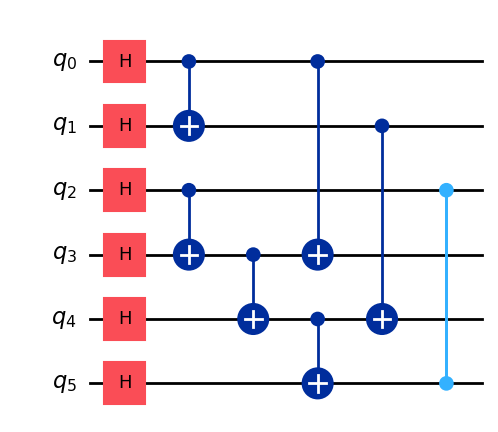

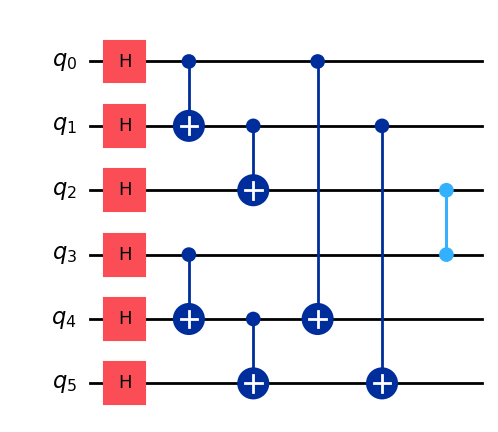

In [10]:
print("Subcircuit A")
subA.draw("mpl");

print("Subcircuit B")
subB.draw("mpl");

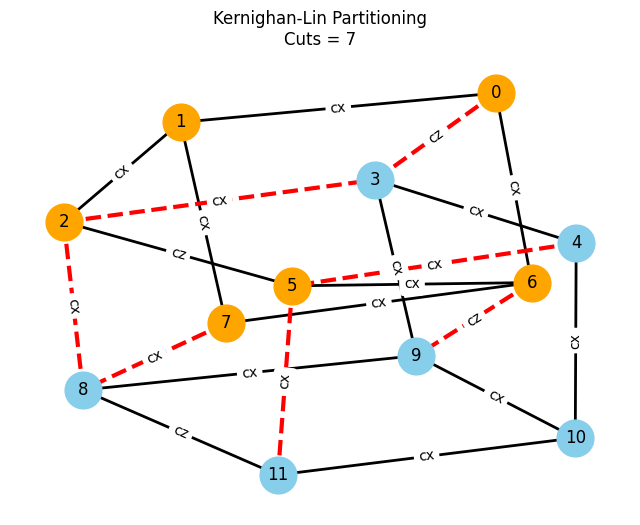

In [11]:
plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

cut_edges = [(u, v) for u, v, gate in cut_edges]

normal_edges = []

for e in G.edges():

    if e not in cut_edges and (e[1], e[0]) not in cut_edges:
        normal_edges.append(e)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(partA),
    node_color="skyblue",
    node_size=700
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=list(partB),
    node_color="orange",
    node_size=700
)

nx.draw_networkx_labels(G, pos)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=normal_edges,
    width=2
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=cut_edges,
    edge_color="red",
    style="dashed",
    width=3
)

edge_labels = nx.get_edge_attributes(G, "gate")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title(
    f"Kernighan-Lin Partitioning\nCuts = {minimum_cut_count}"
)

plt.axis("off")
plt.show()

In [12]:
import time

start = time.time()

partA, partB = kernighan_lin_bisection(G)

end = time.time()

runtime = end - start

print("Runtime =", runtime, "seconds")

Runtime = 0.0009984970092773438 seconds
